<h1>Closed-loop learning as an inference method</h1>

<h3>Gabriele Cerioli, BSc Physics UNITS, Intership Abdus Salam's International Centre for Theoretical Physics</h3>

In [1]:
import numpy as np

# create a random number generator
rng = np.random.default_rng()

# Parameters
mean_0 = 10        # center of the distribution
std_dev = 10     # standard deviation (spread)
n_samples = 1000  # number of values to generate


# Generate samples
samples = rng.normal(loc=float(mean_0), scale=float(std_dev), size=int(n_samples))

#print(samples)

In [2]:
def mean_estimator(samples):
    mean=np.average(samples)
    return mean

mean=mean_estimator(samples)
print(mean_estimator(samples))

def variance_estimator(samples):
    variance=np.var(samples)
    return variance
variance=variance_estimator(samples)
print(np.sqrt(variance_estimator(samples)))

9.97409330578036
10.209781493662044


In [3]:
def samples_updator(samples, M):
    synthetic=rng.normal(loc=float(mean_estimator(samples)), scale=float(np.sqrt(variance_estimator(samples))), size=int(n_samples))
    new_sample=np.concatenate((samples,synthetic))
    return new_sample

samples=samples_updator(samples,1)

print(mean_estimator(samples))

10.00647334466644


In [4]:
it=100
for i in range(0,it):
    samples=samples_updator(samples,10)
    mean_updated=mean_estimator(samples)
    variance_updated=variance_estimator(samples)

In [5]:
print("Original mean:", mean)
print("Mean after CLL: ", mean_updated)
print("Original STD_DEV: ", np.sqrt(variance))
print("STD_DEV after CLL: ", np.sqrt(variance_updated))

Original mean: 9.97409330578036
Mean after CLL:  9.98348277374325
Original STD_DEV:  10.209781493662044
STD_DEV after CLL:  10.075027678372003


<h2>Let's define a metric to see if CLL helped us estimate the parameters</h2>

In [6]:
quality_mean=(np.abs(np.sqrt(mean)-mean_0)-np.abs(np.sqrt(mean_updated)-mean_0))*100/mean
print("Quality of CLL on mean estimation:",quality_mean)

quality_stdev=(np.abs(np.sqrt(variance)-std_dev)-np.abs(np.sqrt(variance_updated)-std_dev))*100/np.sqrt(variance)
print("Quality of CLL on standard deviation estimation:", quality_stdev)


Quality of CLL on mean estimation: 0.014900425666097126
Quality of CLL on standard deviation estimation: 1.3198501395323017


In [7]:
import random
trials=10000
mean_quality_total=0
stdev_quality_total=0
it=10
n_samples=300
mean_total_quality=[]
stddev_total_quality=[]
for j in range (trials):
    mean_0 = random.randint(1,10)        # center of the distribution
    std_dev =random.randint(1,10)     # standard deviation (spread)
    # Generate samples
    samples = rng.normal(loc=float(mean_0), scale=float(std_dev), size=n_samples)
    mean=mean_estimator(samples)
    variance=variance_estimator(samples)
    for i in range(0,it):
        samples=samples_updator(samples,10)
    mean_updated=mean_estimator(samples)
    variance_updated=variance_estimator(samples)
    quality_mean=(np.abs(mean-mean_0)-np.abs(mean_updated-mean_0))/mean_0
    quality_stdev=(np.abs(np.sqrt(variance)-std_dev)-np.abs(np.sqrt(variance_updated)-std_dev))/std_dev
    mean_quality_total+=quality_mean
    stdev_quality_total+=quality_stdev
    mean_total_quality.append(quality_mean)
    stddev_total_quality.append(quality_stdev)

print("Average mean quality:", mean_quality_total/trials)
print("Average stdev quality: ", stdev_quality_total/trials)

Average mean quality: -0.01801974433750926
Average stdev quality:  -0.008036339873494404


<h3>Let's do an histogram of the mean and stddev</h3>

[-0.031183055624137257, -0.0256565486546958, 0.015029482245744852, -0.03522402097886679, 0.024672129563486633, -0.007313480675850137, -0.0232657961126832, -0.004911308624246225, -0.014009522176373222, -0.002976331598159465, 0.04278802249187774, -0.024156933875792496, -0.01566694290994053, -0.008000181958655084, 0.00031452299439020947, -0.00037469626652253396, -0.009081482508773853, 0.004756201685162997, 0.04724326793841449, -0.003976765271063165, -0.0069777296819595325, 0.016513546133301766, 0.012694866204560173, 0.0033073363144442425, 0.009301462560931917, 0.03823751491156422, 0.011153008233801564, 0.013911449639743978, 0.010311308353768566, 0.00048674117165840397, -0.050303977493384, -0.031034008518531664, 0.02016208394218655, -0.0341721980886458, 0.006419012783099579, -0.00326430870340777, -0.024699922678411163, -0.0717356234263653, -0.007738532959197464, 0.01923590996967602, -0.005455176534544926, -0.06508950670024416, 0.009406878174685366, 0.008052679873787837, -0.0247524683054179

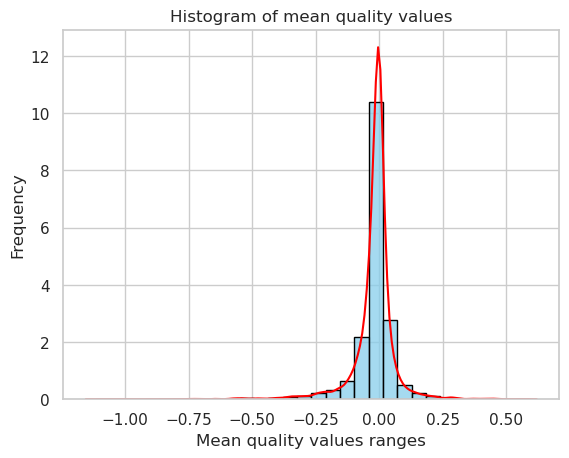

In [8]:
print(stddev_total_quality)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.histplot(mean_total_quality, bins=30, kde=False, color="skyblue",edgecolor="black", stat="density")
sns.kdeplot(mean_total_quality, color="red")
plt.title("Histogram of mean quality values")
plt.xlabel("Mean quality values ranges")
plt.ylabel("Frequency")

plt.show()

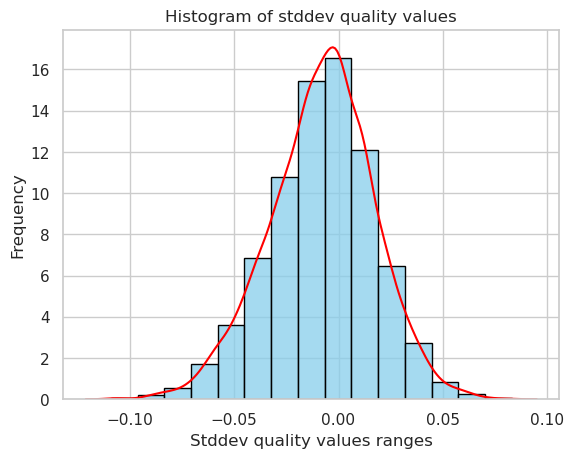

In [9]:
sns.set(style="whitegrid")
sns.histplot(stddev_total_quality, bins=15, kde=False, color="skyblue",edgecolor="black", stat="density")
sns.kdeplot(stddev_total_quality, color="red")
plt.title("Histogram of stddev quality values")
plt.xlabel("Stddev quality values ranges")
plt.ylabel("Frequency")

plt.show()